In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("C:/Users/keshv/OneDrive/Desktop/Data_Science/Jupyter lab/07 Machine learning/vehicles.csv")

In [5]:
df.shape

(426880, 26)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [7]:
len(df.select_dtypes(include = "object").columns)

19

In [8]:
len(df.select_dtypes(include = "number").columns)

7

In [9]:
df = df.drop(columns = ["id", "url", "region_url", "VIN", "image_url", "description", "county", "state", "lat", "long"])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        426880 non-null  object 
 1   price         426880 non-null  int64  
 2   year          425675 non-null  float64
 3   manufacturer  409234 non-null  object 
 4   model         421603 non-null  object 
 5   condition     252776 non-null  object 
 6   cylinders     249202 non-null  object 
 7   fuel          423867 non-null  object 
 8   odometer      422480 non-null  float64
 9   title_status  418638 non-null  object 
 10  transmission  424324 non-null  object 
 11  drive         296313 non-null  object 
 12  size          120519 non-null  object 
 13  type          334022 non-null  object 
 14  paint_color   296677 non-null  object 
 15  posting_date  426812 non-null  object 
dtypes: float64(2), int64(1), object(13)
memory usage: 52.1+ MB


In [11]:
df

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,posting_date
0,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,fwd,NaN,sedan,NaN,2021-04-04T03:21:31-0600
426876,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,fwd,NaN,sedan,red,2021-04-04T03:21:29-0600
426877,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,NaN,NaN,hatchback,white,2021-04-04T03:21:17-0600
426878,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,fwd,NaN,sedan,silver,2021-04-04T03:21:11-0600


In [12]:
df["cylinders"].unique()

array([nan, '8 cylinders', '6 cylinders', '4 cylinders', '5 cylinders',
       'other', '3 cylinders', '10 cylinders', '12 cylinders'],
      dtype=object)

In [13]:
df["title_status"].unique()

array([nan, 'clean', 'rebuilt', 'lien', 'salvage', 'missing',
       'parts only'], dtype=object)

In [14]:
df["transmission"].unique()

array([nan, 'other', 'automatic', 'manual'], dtype=object)

In [15]:
df["drive"].unique()

array([nan, 'rwd', '4wd', 'fwd'], dtype=object)

In [16]:
df["size"].unique()

array([nan, 'full-size', 'mid-size', 'compact', 'sub-compact'],
      dtype=object)

In [17]:
df["fuel"].unique()

array([nan, 'gas', 'other', 'diesel', 'hybrid', 'electric'], dtype=object)

In [18]:
df["condition"].unique()

array([nan, 'good', 'excellent', 'fair', 'like new', 'new', 'salvage'],
      dtype=object)

In [19]:
df["type"].unique()

array([nan, 'pickup', 'truck', 'other', 'coupe', 'SUV', 'hatchback',
       'mini-van', 'sedan', 'offroad', 'bus', 'van', 'convertible',
       'wagon'], dtype=object)

In [20]:
df["paint_color"].unique()

array([nan, 'white', 'blue', 'red', 'black', 'silver', 'grey', 'brown',
       'yellow', 'orange', 'green', 'custom', 'purple'], dtype=object)

In [21]:
df["condition"] = df["condition"].map({"salvage" : 0, "fair" : 1, "good" : 2, "excellent" : 3, "like new" : 4, "new" : 5})
df["size"] = df["size"].map({"sub-compact" : 0, "compact" : 1, "mid-size" : 2, "full-size" : 3})
df["cylinders"] = df["cylinders"].map({"3 cylinders" : 3, "4 cylinders" : 4, "5 cylinders" : 5, "6 cylinders" : 6, "8 cylinders" : 8, "10 cylinders" : 10, "12 cylinders" : 12})

In [22]:
df = pd.get_dummies(df, columns = ["fuel", "title_status", "transmission", "drive"], dtype = "int")

In [23]:
df["posting_date"]

0                              NaN
1                              NaN
2                              NaN
3                              NaN
4                              NaN
                    ...           
426875    2021-04-04T03:21:31-0600
426876    2021-04-04T03:21:29-0600
426877    2021-04-04T03:21:17-0600
426878    2021-04-04T03:21:11-0600
426879    2021-04-04T03:21:07-0600
Name: posting_date, Length: 426880, dtype: object

In [24]:
df["posting_date"] = pd.to_datetime(
    df["posting_date"],
    utc=True,
    errors="coerce"
)
df["car_age"] = df["posting_date"].dt.year - df["year"]

In [25]:
df

,region,price,year,manufacturer,model,condition,cylinders,odometer,size,type,...,title_status_parts only,title_status_rebuilt,title_status_salvage,transmission_automatic,transmission_manual,transmission_other,drive_4wd,drive_fwd,drive_rwd,car_age
0,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,NaN
1,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,NaN
2,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,NaN
3,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,NaN
4,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,wyoming,23590,2019.0,nissan,maxima s sedan 4d,2.0,6.0,32226.0,NaN,sedan,...,0,0,0,0,0,1,0,1,0,2.0
426876,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,2.0,NaN,12029.0,NaN,sedan,...,0,0,0,0,0,1,0,1,0,1.0
426877,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,2.0,NaN,4174.0,NaN,hatchback,...,0,0,0,0,0,1,0,0,0,1.0
426878,wyoming,28990,2018.0,lexus,es 350 sedan 4d,2.0,6.0,30112.0,NaN,sedan,...,0,0,0,0,0,1,0,1,0,3.0


In [26]:
df.isnull().sum().sort_values(ascending = False)

size                       306361
cylinders                  178976
condition                  174104
paint_color                130203
type                        92858
manufacturer                17646
model                        5277
odometer                     4400
car_age                      1205
year                         1205
posting_date                   68
title_status_parts only         0
drive_rwd                       0
drive_fwd                       0
drive_4wd                       0
transmission_other              0
transmission_manual             0
transmission_automatic          0
title_status_salvage            0
title_status_rebuilt            0
region                          0
title_status_missing            0
title_status_lien               0
title_status_clean              0
fuel_other                      0
price                           0
fuel_gas                        0
fuel_electric                   0
fuel_diesel                     0
fuel_hybrid   

In [27]:
df[["condition", "paint_color"]] = df[["condition", "paint_color"]].fillna("unknown")
df = df.drop(columns = "size")

In [28]:
df.groupby("model")["manufacturer"].nunique().sort_values(ascending = False)

model
truck                           11
van                             10
coupe                            9
convertible                      9
pickup                           9
                                ..
International 2574               0
International 300                0
International 3700 carpenter     0
International 3800               0
🔥GMC Sierra 1500 SLE🔥 4X4 🔥      0
Name: manufacturer, Length: 29667, dtype: int64

In [29]:
df.isnull().sum().sort_values(ascending = False)

cylinders                  178976
type                        92858
manufacturer                17646
model                        5277
odometer                     4400
car_age                      1205
year                         1205
posting_date                   68
transmission_manual             0
title_status_rebuilt            0
title_status_salvage            0
transmission_automatic          0
drive_fwd                       0
transmission_other              0
drive_4wd                       0
title_status_missing            0
drive_rwd                       0
title_status_parts only         0
region                          0
title_status_lien               0
title_status_clean              0
fuel_other                      0
price                           0
fuel_gas                        0
fuel_electric                   0
fuel_diesel                     0
paint_color                     0
condition                       0
fuel_hybrid                     0
dtype: int64

In [30]:
df.drop(index = df[df["model"].isnull()].index, inplace = True)
df.drop(index = df[df["manufacturer"].isnull()].index, inplace = True)
df.drop(index = df[df["year"].isnull()].index, inplace = True)

In [31]:
df["odometer"] = df["odometer"].fillna(df["odometer"].median())
df["type"] = df["type"].fillna("unknown")

In [32]:
df.groupby("model")["cylinders"].nunique().sort_values(ascending = False)

model
altima                    6
malibu                    6
beetle                    5
camaro                    5
tacoma                    5
                         ..
colorado ls z71 4x4       0
q50 3.0 premium           0
q50 2.0t pure sedan 4d    0
q50 2.0t luxe sedan 4d    0
chassis 5500              0
Name: cylinders, Length: 23753, dtype: int64

In [33]:
df.drop(columns = "cylinders", inplace = True)

In [34]:
df.isnull().sum().sum()

0

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 404020 entries, 27 to 426879
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype              
---  ------                   --------------   -----              
 0   region                   404020 non-null  object             
 1   price                    404020 non-null  int64              
 2   year                     404020 non-null  float64            
 3   manufacturer             404020 non-null  object             
 4   model                    404020 non-null  object             
 5   condition                404020 non-null  object             
 6   odometer                 404020 non-null  float64            
 7   type                     404020 non-null  object             
 8   paint_color              404020 non-null  object             
 9   posting_date             404020 non-null  datetime64[ns, UTC]
 10  fuel_diesel              404020 non-null  int32              
 11  fuel_electric    

In [36]:
df.drop_duplicates(inplace = True)

In [37]:
df.duplicated().sum()

0

In [38]:
np.isinf(df.select_dtypes(include="number")).sum().sum()

0

In [39]:
df["price"].describe()

count    4.039920e+05
mean     6.218861e+04
std      1.124293e+07
min      0.000000e+00
25%      5.995000e+03
50%      1.399500e+04
75%      2.642400e+04
max      3.736929e+09
Name: price, dtype: float64

In [40]:
[columns for columns in df.columns if df[columns].dtype == "O"]

['region', 'manufacturer', 'model', 'condition', 'type', 'paint_color']

In [41]:
print(df["model"].nunique())
print(df["manufacturer"].nunique())
print(df["region"].nunique())
print(df["type"].nunique())
print(df["condition"].nunique())
print(df["paint_color"].nunique())

23753
41
404
14
7
13


In [42]:
df = pd.get_dummies(df, columns = ["manufacturer", "type", "condition", "paint_color"], dtype = int)

In [43]:
df.drop(columns = ["model", "region", "posting_date"], inplace = True)

In [44]:
print(df["price"].describe())
print((df["price"] == 0).sum())
print((df["price"] < 0).sum())
print(df["price"].max())

count    4.039920e+05
mean     6.218861e+04
std      1.124293e+07
min      0.000000e+00
25%      5.995000e+03
50%      1.399500e+04
75%      2.642400e+04
max      3.736929e+09
Name: price, dtype: float64
30862
0
3736928711


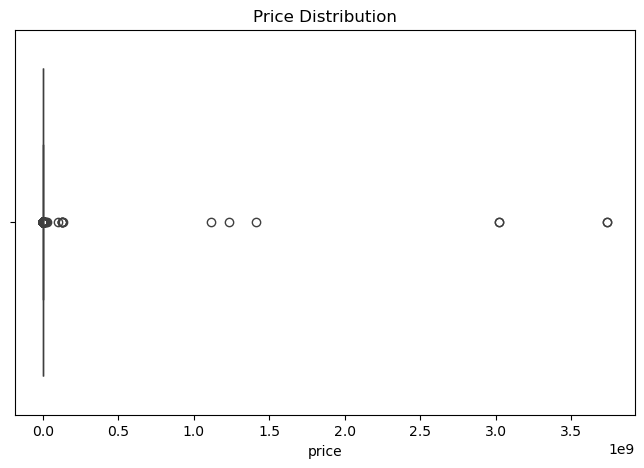

In [45]:
plt.figure(figsize = (8, 5))
sns.boxplot(x = df["price"])
plt.title("Price Distribution")
plt.show()

In [46]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["price"] >= lower) & (df["price"] <= upper)]

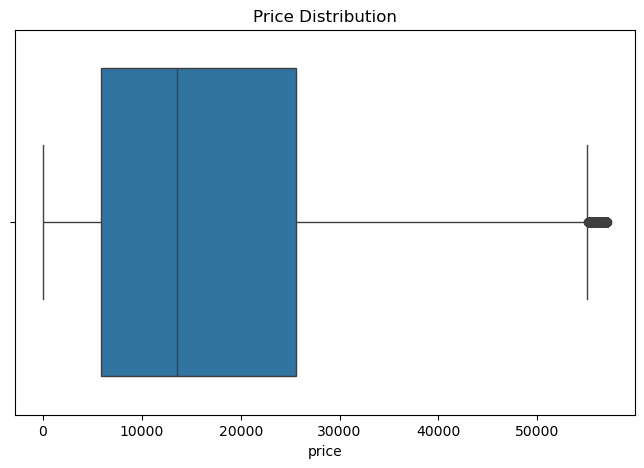

In [47]:
plt.figure(figsize = (8, 5))
sns.boxplot(x = df["price"])
plt.title("Price Distribution")
plt.show()

In [48]:
df.corr()

,price,year,odometer,fuel_diesel,fuel_electric,fuel_gas,fuel_hybrid,fuel_other,title_status_clean,title_status_lien,...,paint_color_custom,paint_color_green,paint_color_grey,paint_color_orange,paint_color_purple,paint_color_red,paint_color_silver,paint_color_unknown,paint_color_white,paint_color_yellow
price,1.000000,0.333873,-0.168015,0.152191,0.033173,-0.217593,-0.018722,0.167439,0.074095,0.014766,...,-0.017006,-0.043014,-0.052647,0.003928,-0.008837,0.019989,-0.032379,-0.084073,0.103158,0.002317
year,0.333873,1.000000,-0.174940,-0.023717,0.032469,-0.098464,0.027835,0.131822,0.005449,0.006116,...,-0.037943,-0.106482,0.001811,-0.019501,-0.027105,-0.032621,0.017572,-0.033828,0.071781,-0.062646
odometer,-0.168015,-0.174940,1.000000,0.048827,-0.018570,0.017410,-0.004352,-0.060933,-0.004531,-0.000053,...,0.009532,0.022263,0.010623,-0.006549,0.001753,-0.008836,0.000061,0.021312,-0.013198,-0.001697
fuel_diesel,0.152191,-0.023717,0.048827,1.000000,-0.015262,-0.581442,-0.027766,-0.067360,0.011573,0.012369,...,-0.008718,-0.003537,-0.027323,-0.011624,-0.007262,-0.017983,-0.040919,0.044259,0.069782,-0.004030
fuel_electric,0.033173,0.032469,-0.018570,-0.015262,1.000000,-0.148756,-0.007104,-0.017234,0.006967,0.005802,...,-0.005003,-0.007160,-0.004385,-0.000550,-0.002433,-0.009042,-0.000592,-0.004669,0.024992,-0.003517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
paint_color_red,0.019989,-0.032621,-0.008836,-0.017983,-0.009042,0.002665,-0.005561,0.019106,0.017334,0.001647,...,-0.034994,-0.035828,-0.068850,-0.018503,-0.010748,1.000000,-0.093999,-0.180885,-0.130985,-0.018250
paint_color_silver,-0.032379,0.017572,0.000061,-0.040919,-0.000592,0.015928,0.014240,0.009523,0.022323,0.003593,...,-0.043177,-0.044206,-0.084951,-0.022830,-0.013261,-0.093999,1.000000,-0.223187,-0.161617,-0.022518
paint_color_unknown,-0.084073,-0.033828,0.021312,0.044259,-0.004669,-0.003756,-0.005570,-0.038136,-0.099926,-0.021065,...,-0.083087,-0.085068,-0.163473,-0.043933,-0.025519,-0.180885,-0.223187,1.000000,-0.311006,-0.043332
paint_color_white,0.103158,0.071781,-0.013198,0.069782,0.024992,-0.064835,0.001332,0.022609,0.046791,0.005709,...,-0.060166,-0.061601,-0.118377,-0.031813,-0.018479,-0.130985,-0.161617,-0.311006,1.000000,-0.031378


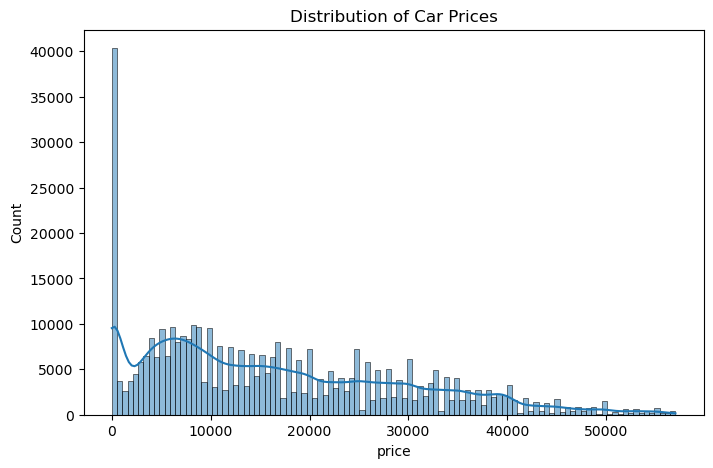

In [49]:
plt.figure(figsize = (8, 5))
sns.histplot(df["price"], kde = True)
plt.title("Distribution of Car Prices")
plt.show()

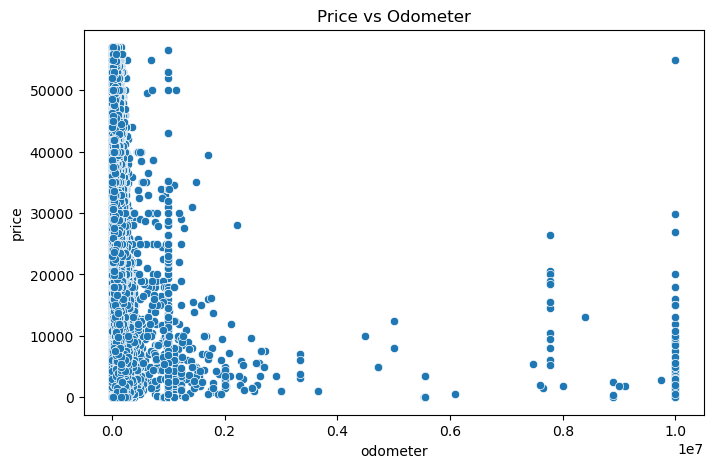

In [51]:
plt.figure(figsize = (8, 5))
sns.scatterplot(x = "odometer", y = "price", data = df)
plt.title("Price vs Odometer")
plt.show()

In [ ]:
pd.to_csv("Clean Vehicles.csv")